# Model Calibration Analysis
Reuses cached prediction probabilities -- no models, no GPU needed. Measures
whether each model's confidence scores are trustworthy: does a prediction
made with 90% confidence turn out to be correct ~90% of the time? This
directly follows up on the earlier finding that these models are frequently
100% confident (which caused vanishing Grad-CAM gradients) -- here we
quantify that overconfidence properly via Expected Calibration Error (ECE)
and reliability diagrams.

## Cell 1 — Setup + load cached predictions

In [1]:
import numpy as np
import pandas as pd
import json as jsonlib
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

cache = '/content/drive/MyDrive/thesis_ensemble_outputs/significance_test_cache'

pred_swin = np.load(f'{cache}/pred_swin.npy')
pred_vit = np.load(f'{cache}/pred_vit.npy')
pred_resnet = np.load(f'{cache}/pred_resnet.npy')
pred_densenet = np.load(f'{cache}/pred_densenet.npy')
pred_efficientnet = np.load(f'{cache}/pred_efficientnet.npy')
pred_levit = np.load(f'{cache}/pred_levit.npy')
ensemble_probs = np.load(f'{cache}/ensemble_probs.npy')
true_labels = np.load(f'{cache}/true_labels.npy')

print("Loaded. Test set size:", len(true_labels))

Mounted at /content/drive
Loaded. Test set size: 2538


## Cell 2 — Calibration function (ECE + reliability-diagram bins)
Standard confidence calibration: bins predictions by their MAX predicted
probability (the model's confidence in its own top choice), and compares
average confidence to observed accuracy within each bin.

In [2]:
def compute_calibration(probs, true_labels, n_bins=10):
    pred_labels = np.argmax(probs, axis=1)
    confidences = np.max(probs, axis=1)
    correct = (pred_labels == true_labels).astype(float)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_accs, bin_confs, bin_counts = [], [], []
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        if i == 0:
            in_bin = (confidences >= lo) & (confidences <= hi)
        else:
            in_bin = (confidences > lo) & (confidences <= hi)
        count = int(np.sum(in_bin))
        if count > 0:
            acc = float(np.mean(correct[in_bin]))
            conf = float(np.mean(confidences[in_bin]))
            ece += (count / len(confidences)) * abs(acc - conf)
        else:
            acc, conf = 0.0, (lo + hi) / 2
        bin_accs.append(acc)
        bin_confs.append(conf)
        bin_counts.append(count)

    return {
        "ece": ece,
        "bin_accs": np.array(bin_accs),
        "bin_confs": np.array(bin_confs),
        "bin_counts": np.array(bin_counts),
        "bin_edges": bin_edges,
        "mean_confidence": float(np.mean(confidences)),
        "accuracy": float(np.mean(correct)),
    }

print("Calibration function ready")

Calibration function ready


## Cell 3 — Compute ECE for all 7 models, build summary table

In [3]:
all_models = {
    "Swin": pred_swin,
    "ViT": pred_vit,
    "LeViT": pred_levit,
    "ResNet50": pred_resnet,
    "DenseNet121": pred_densenet,
    "EfficientNetB0": pred_efficientnet,
    "Proposed Ensemble": ensemble_probs,
}

calibration_results = {}
rows = []
for name, probs in all_models.items():
    result = compute_calibration(probs, true_labels, n_bins=10)
    calibration_results[name] = result
    rows.append({
        "Model": name,
        "Accuracy": round(result["accuracy"] * 100, 2),
        "Mean Confidence": round(result["mean_confidence"] * 100, 2),
        "Overconfidence Gap": round((result["mean_confidence"] - result["accuracy"]) * 100, 2),
        "ECE": round(result["ece"], 4),
    })

calib_df = pd.DataFrame(rows).sort_values("ECE")
print(calib_df.to_string(index=False))

output_folder = '/content/drive/MyDrive/thesis_ensemble_outputs'
calib_df.to_csv(f'{output_folder}/calibration_summary.csv', index=False)
print(f"\nSaved to: {output_folder}/calibration_summary.csv")

            Model  Accuracy  Mean Confidence  Overconfidence Gap    ECE
   EfficientNetB0     97.68            97.31               -0.36 0.0050
Proposed Ensemble     98.86            98.52               -0.34 0.0060
      DenseNet121     96.89            97.25                0.36 0.0074
             Swin     98.42            99.09                0.66 0.0094
         ResNet50     97.95            99.15                1.20 0.0121
              ViT     98.23            99.37                1.15 0.0124
            LeViT     95.15            96.96                1.81 0.0188

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/calibration_summary.csv


## Cell 4 — Reliability diagram: proposed ensemble (main figure)
Bars show observed accuracy per confidence bin; the diagonal line is
perfect calibration. Bars BELOW the diagonal = overconfident (the model
claims more certainty than it delivers).

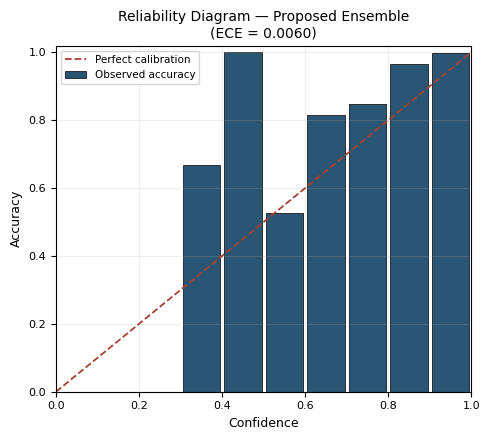

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/reliability_diagram_ensemble.png

Bin-by-bin detail (Proposed Ensemble):
  [0.0-0.1]  n=    0  avg_confidence=0.050  observed_accuracy=0.000
  [0.1-0.2]  n=    0  avg_confidence=0.150  observed_accuracy=0.000
  [0.2-0.3]  n=    0  avg_confidence=0.250  observed_accuracy=0.000
  [0.3-0.4]  n=    3  avg_confidence=0.379  observed_accuracy=0.667
  [0.4-0.5]  n=    1  avg_confidence=0.440  observed_accuracy=1.000
  [0.5-0.6]  n=   19  avg_confidence=0.553  observed_accuracy=0.526
  [0.6-0.7]  n=   27  avg_confidence=0.663  observed_accuracy=0.815
  [0.7-0.8]  n=   33  avg_confidence=0.748  observed_accuracy=0.848
  [0.8-0.9]  n=   28  avg_confidence=0.857  observed_accuracy=0.964
  [0.9-1.0]  n= 2427  avg_confidence=0.998  observed_accuracy=0.997


In [10]:
result = calibration_results["Proposed Ensemble"]
bin_edges = result["bin_edges"]
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.bar(bin_centers, result["bin_accs"], width=bin_width * 0.9, color='#2A5674',
       edgecolor='black', linewidth=0.5, label='Observed accuracy')
ax.plot([0, 1], [0, 1], color='#A6402F', linestyle='--', linewidth=1.3, label='Perfect calibration')

ax.set_xlabel('Confidence', fontsize=9)
ax.set_ylabel('Accuracy', fontsize=9)
ax.set_title(f'Reliability Diagram — Proposed Ensemble\n(ECE = {result["ece"]:.4f})', fontsize=10)
ax.tick_params(labelsize=8)
ax.legend(fontsize=7.5, loc='upper left')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig(f'{output_folder}/reliability_diagram_ensemble.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to: {output_folder}/reliability_diagram_ensemble.png")

print("\nBin-by-bin detail (Proposed Ensemble):")
for lo, hi, acc, conf, cnt in zip(bin_edges[:-1], bin_edges[1:], result["bin_accs"], result["bin_confs"], result["bin_counts"]):
    print(f"  [{lo:.1f}-{hi:.1f}]  n={cnt:5d}  avg_confidence={conf:.3f}  observed_accuracy={acc:.3f}")

## Cell 5 (bonus) — Reliability diagrams for all 7 models, side by side
Compact grid for comparing calibration quality across architectures.

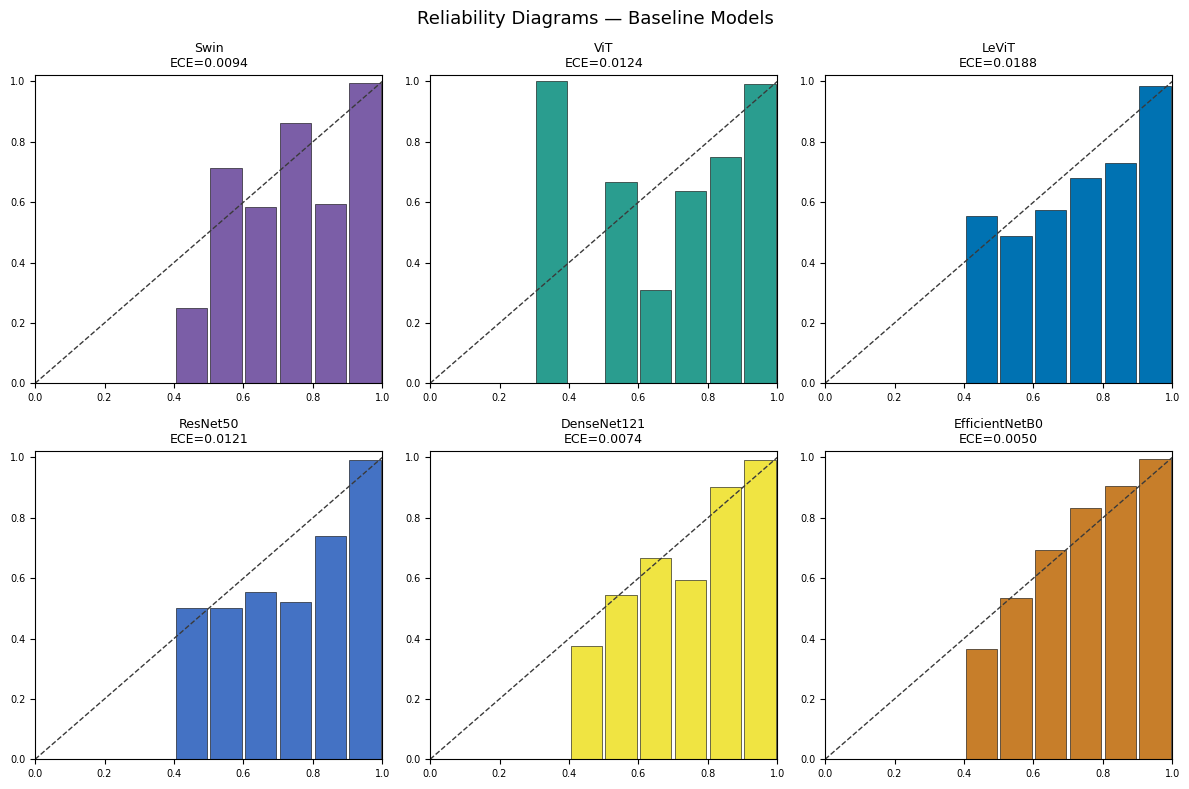

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/reliability_diagrams_all_models.png


In [8]:
model_colors = {
    "Swin":               "#7B5EA7",  # purple
    "ViT":                "#2A9D8F",  # teal
    "ResNet50":           "#4472C4",  # blue
    "EfficientNetB0":     "#C77E2A",  # orange
    "DenseNet121":        "#F0E442",  # yellow
    "LeViT":              "#0072B2",  #
}

# exclude Proposed Ensemble, keep only the six baselines
baseline_results = {k: v for k, v in calibration_results.items() if k != "Proposed Ensemble"}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, (name, result) in enumerate(baseline_results.items()):
    ax = axes[idx]
    color = model_colors.get(name, "#8C8C8C")
    bin_edges = result["bin_edges"]
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    ax.bar(bin_centers, result["bin_accs"], width=bin_width * 0.9, color=color, edgecolor='black', linewidth=0.4)
    ax.plot([0, 1], [0, 1], color='#3A3A3A', linestyle='--', linewidth=1)
    ax.set_title(f"{name}\nECE={result['ece']:.4f}", fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.tick_params(labelsize=7)

plt.suptitle('Reliability Diagrams — Baseline Models', fontsize=13)
plt.tight_layout()
plt.savefig(f'{output_folder}/reliability_diagrams_all_models.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved to: {output_folder}/reliability_diagrams_all_models.png")